## **NOTE: Code intended for SLEAP 1.3.4**

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import importlib
import scripts.report_sleap_134_version as report

importlib.reload(report)

from scripts.report_sleap_134_version import (
    load_model_pair,
    notebook_report_markdown,
    plot_all
)
from IPython.display import Markdown, display

# Add sleap packages
import sys
sys.path.insert(0, '/ceph/apps/ubuntu-24/packages/SLEAP/2025-09-30/lib/python3.7/site-packages')
import sleap

# QC - sleap model training

### SLEAP Model Details

**Name**  
`260424.abcEphysPilot01`

**Type**  
`Multi-animal top-down (Centroid + Centered Instance)`

**Project folder**  
`/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01`

**Training data**  
`/ceph/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments`

**Labels**  
`abcEphysPilot01_labels.slp`

**Custom settings**  
- Anchor part: `corner_1`
- Centroid sigma: `5`
- Instance sigma: `2.5`
- Centroid scale: `0.5`
- Instance scale: `1.0`
- Max epochs: `200`

**Config path**  
`/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/`
- `centroid.json`
- `centered_instance.json`

**Goal**  
Train on calibration session cameras and run inference on full videos.

**After training**  
Model folder:  
`/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/models`

- Centroid: `260424.centroid.abcEphysPilot01`
- Centered instance: `260424.centered_instance.abcEphysPilot01`
- Best checkpoint:
- Validation results:
- Inference settings:
- Failure cases:
- Next changes:


In [2]:
# --- Paths ---
CEPH_BASE = Path('/ceph/aeon/aeon/data/raw/AEON3/abcEphysPilot01')
SESSION = '2026-04-14T141851Z_calibrateBeforeAprilExperiments'
SESSION_DIR = CEPH_BASE / SESSION
TIMESTAMP = "2026-04-14T14-00-00"

PREDICTIONS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/predictions')
MODELS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/models')
LABELS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/labels')

# --- Cameras ---
CAMERAS = ['CameraEast', 'CameraNorth', 'CameraSouth', 'CameraWest', 'CameraNest', 'CameraTop']
NODE_ORDER = ["corner_1", "corner_2", "corner_3", "corner_4"]

# --- Quality Threshold ---
CONF_THRESH = 0.7

In [3]:
models = load_model_pair(MODELS_DIR / Path("260424.centroid.abcEphysPilot01"), MODELS_DIR / Path("260424.centered_instance.abcEphysPilot01"))

In [4]:
display(Markdown(notebook_report_markdown(models)))

## Model Report

### Metric guide

- `mOKS`, `mPCK`, `PCK@5`, visibility precision/recall: **near 1 is better**
- Average pixel error, val loss: **lower is better**

### Metric table

| Metric | centroid | instance |
|---|---|---|
| mOKS | 1.000 | 0.525 |
| mPCK | 1.000 | 0.709 |
| PCK@5 | 1.000 | 0.812 |
| vis. precision | 1.000 | 0.967 |
| vis. recall | 1.000 | 0.952 |
| avg pixel error | 0.00px | 6.13px |

### Notes

- Centroid model = detector. Centered-instance model = corner localiser.
- High scores on a small val set can be misleading — always check rendered predictions too.

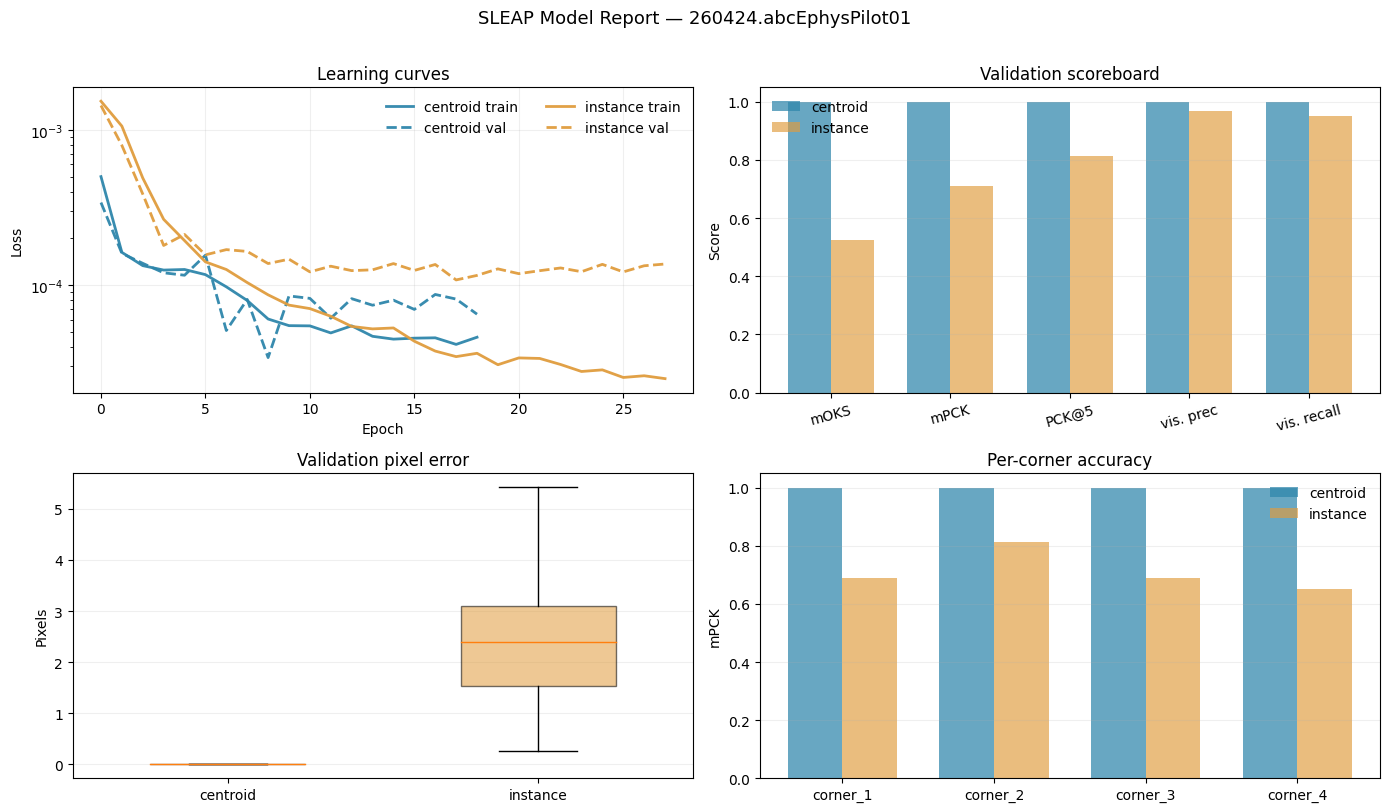

In [5]:
fig = plot_all(models)
plt.show()